Librerie

In [1]:
# ── Librerie standard ────────────────────────────────────────────────────────
import os
import importlib
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
 
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB
from torchvision.models import get_model, resnet18
 
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
 
from tqdm import tqdm
import wandb
 
import engine
importlib.reload(engine)
from engine import train_and_evaluate

import torch.nn.functional as F
import torchvision.transforms.functional as TF
from sklearn.metrics import average_precision_score
import random

Configurazione globale

In [2]:
CFG = {
    # Device
    "device": (
        torch.device("cuda")  if torch.cuda.is_available()         else
        torch.device("mps")   if torch.backends.mps.is_available() else
        torch.device("cpu")
    ),
    # Dataset
    "data_dir":    "data/",
    "image_size":  64,
    "resize_to":   70,
    "norm_mean":   (0.485, 0.456, 0.406),
    "norm_std":    (0.229, 0.224, 0.225),
    # Split
    "val_split":   0.20,
    "random_seed": 42,
    # DataLoader
    "batch_size":  64,
    "num_workers": 4,
    # Modello
    "backbone":    "resnet18",
    "num_classes": 43,
    "feature_dim": 512,
}
 
device = CFG["device"]
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
 
# Mixed Precision disponibile?
use_amp = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7
print(f"Mixed Precision: {'✅ abilitato' if use_amp else '⚠️  non disponibile'}")

Device: cuda
  GPU: NVIDIA GeForce RTX 2050
Mixed Precision: ✅ abilitato


Pre-processing

In [3]:
# Transform standard (usato per validation, test e baseline SVM)
transform_base = T.Compose([
    T.Resize(CFG["resize_to"]),
    T.CenterCrop((CFG["image_size"], CFG["image_size"])),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=CFG["norm_mean"], std=CFG["norm_std"]),
])
 
# Transform con Data Augmentation (usato solo per il training nell'esperimento finale)
transform_augmented = T.Compose([
    T.Resize(CFG["resize_to"]),
    T.RandomCrop((CFG["image_size"], CFG["image_size"])),
    T.RandomRotation(degrees=5),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=CFG["norm_mean"], std=CFG["norm_std"]),
])
 
# Dataset
ds_train_full = GTSRB(CFG["data_dir"], split="train", transform=transform_base, download=True)
ds_test       = GTSRB(CFG["data_dir"], split="test",  transform=transform_base, download=True)
ds_train_raw  = GTSRB(CFG["data_dir"], split="train", transform=None,           download=False)
 
print(f"Train completo : {len(ds_train_full):>6} immagini")
print(f"Test (ufficiale): {len(ds_test):>6} immagini")

Train completo :  26640 immagini
Test (ufficiale):  12630 immagini


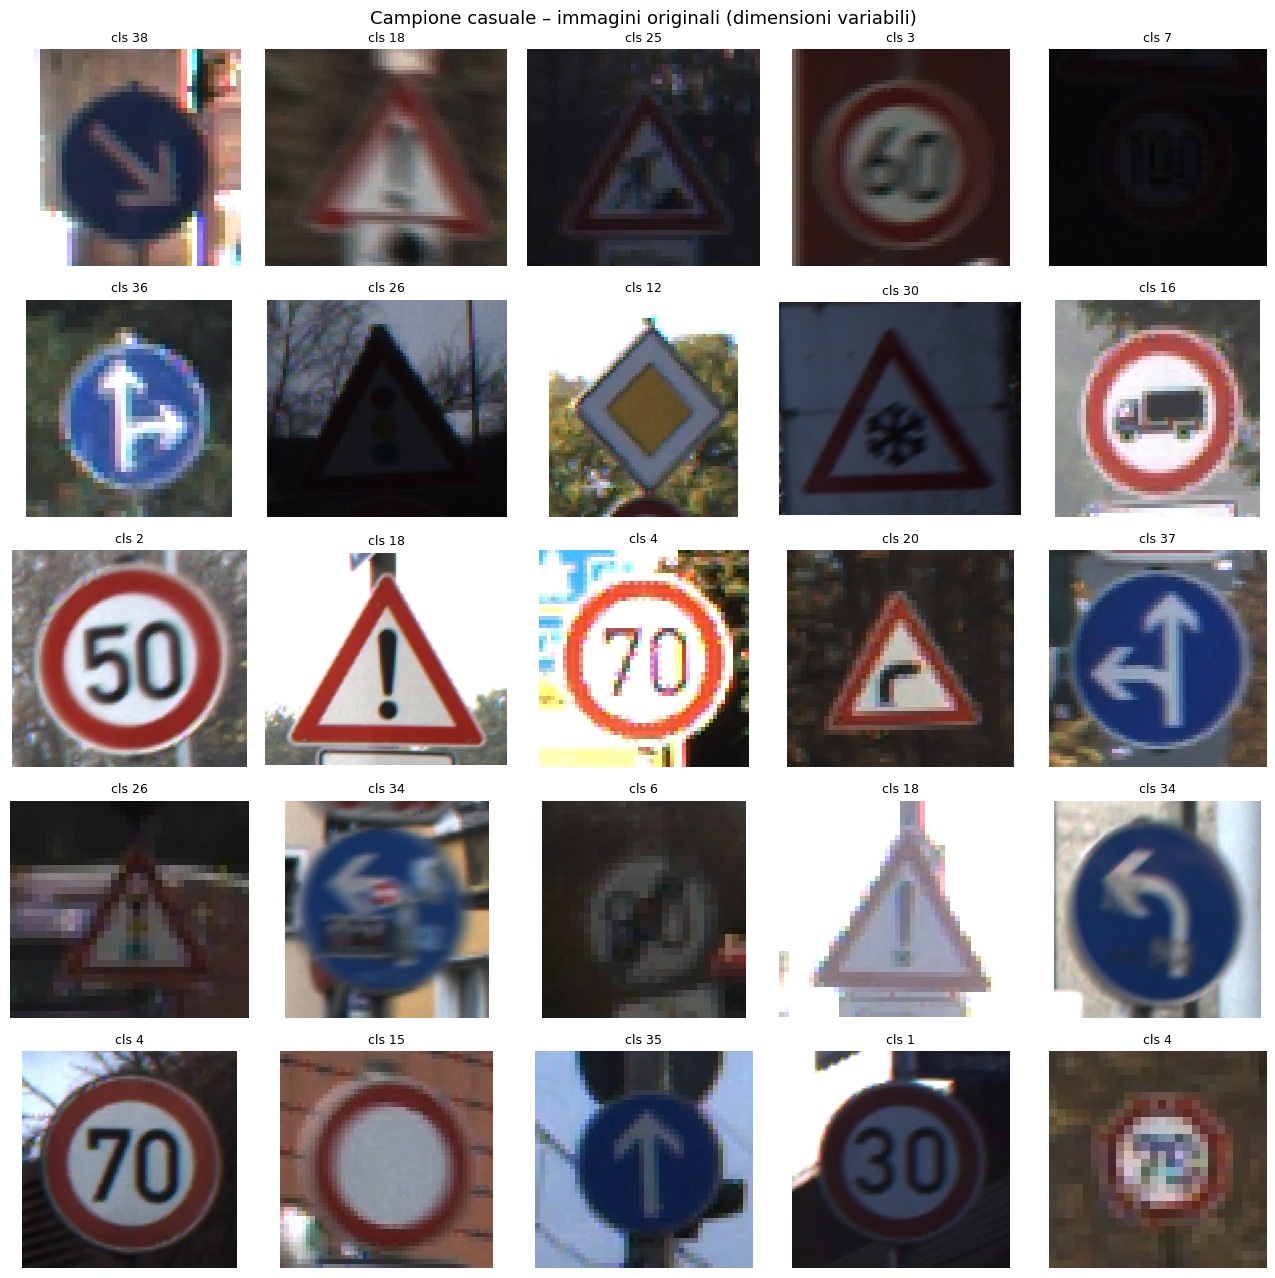

Calcolo statistiche (può richiedere qualche minuto)...
Salvato in df_stats_cache.csv
            CLS    HEIGHT     WIDTH        AR
count  26640.00  26640.00  26640.00  26640.00
mean      15.89     50.37     50.93      1.01
std       12.04     23.16     24.37      0.07
min        0.00     25.00     25.00      0.37
25%        5.00     35.00     35.00      0.97
50%       12.00     43.00     43.00      1.00
75%       25.00     58.00     58.00      1.04
max       42.00    225.00    243.00      1.42


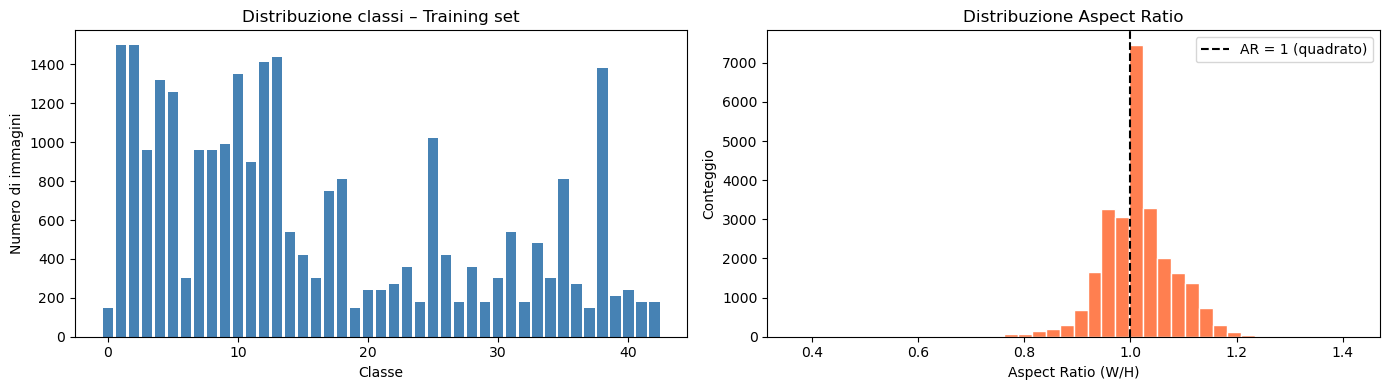


Classe più frequente : 1 (1500 img)
Classe meno frequente: 0 (150 img)
Rapporto max/min     : 10.0×


In [4]:
# 4.1 – Campione visivo
n = 25
indices = np.random.choice(len(ds_train_raw), n, replace=False)
 
fig, axes = plt.subplots(5, 5, figsize=(13, 13))
for ax, idx in zip(axes.flat, indices):
    im, cls = ds_train_raw[idx]
    ax.imshow(im)
    ax.set_title(f"cls {cls}", fontsize=9)
    ax.axis("off")
fig.suptitle("Campione casuale – immagini originali (dimensioni variabili)", fontsize=13)
plt.tight_layout()
plt.show()
 
# %%
# 4.2 – Statistiche dimensionali con cache
cache_path = "df_stats_cache.csv"
 
if os.path.exists(cache_path):
    print("Caricamento statistiche dalla cache...")
    df = pd.read_csv(cache_path)
else:
    print("Calcolo statistiche (può richiedere qualche minuto)...")
    df = pd.DataFrame(
        [(cls, im.size[1], im.size[0]) for im, cls in ds_train_raw],
        columns=["CLS", "HEIGHT", "WIDTH"]
    )
    df["AR"] = df["WIDTH"] / df["HEIGHT"]
    df.to_csv(cache_path, index=False)
    print(f"Salvato in {cache_path}")
 
print(df.describe().round(2))
 
# %%
# 4.3 – Distribuzione classi e Aspect Ratio
class_counts = df["CLS"].value_counts().sort_index()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(class_counts.index, class_counts.values, color="steelblue", width=0.8)
axes[0].set(xlabel="Classe", ylabel="Numero di immagini", title="Distribuzione classi – Training set")
 
axes[1].hist(df["AR"], bins=40, color="coral", edgecolor="white")
axes[1].axvline(1.0, color="black", linestyle="--", label="AR = 1 (quadrato)")
axes[1].set(xlabel="Aspect Ratio (W/H)", ylabel="Conteggio", title="Distribuzione Aspect Ratio")
axes[1].legend()
 
plt.tight_layout()
plt.show()
 
print(f"\nClasse più frequente : {class_counts.idxmax()} ({class_counts.max()} img)")
print(f"Classe meno frequente: {class_counts.idxmin()} ({class_counts.min()} img)")
print(f"Rapporto max/min     : {class_counts.max() / class_counts.min():.1f}×")
 
# %% [markdown]
# ### Analisi EDA
#
# | Osservazione | Impatto |
# |---|---|
# | Immagini a risoluzioni variabili (min ~25px, max ~225px) | Necessario resize uniforme |
# | Aspect Ratio ≈ 1.0 per quasi tutte le immagini | CenterCrop quadrato non distorce i cartelli |
# | Dataset fortemente sbilanciato (~10× tra classe più e meno frequente) | Rischio di bias verso le classi dominanti |
# | 43 classi | Output layer deve avere 43 neuroni |

Split Stratificato: Train / Validation / Test

In [5]:
# **Strategia:**
# - **Test set**: divisione ufficiale GTSRB (invariata – standard di benchmark).
# - **Train → Train reale + Validation**: split stratificato 80/20.
#   Lo stratified split garantisce che ogni classe sia proporzionalmente
#   rappresentata in entrambi i subset, evitando classi assenti in validation.
 
# ## 5. Split Stratificato: Train / Validation / Test
 

all_labels  = [ds_train_full[i][1] for i in range(len(ds_train_full))]
all_indices = list(range(len(ds_train_full)))
 
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=CFG["val_split"],
    random_state=CFG["random_seed"],
    stratify=all_labels,
)
 
ds_train_real = Subset(ds_train_full, train_indices)
ds_val        = Subset(ds_train_full, val_indices)
 
print(f"Train reale : {len(ds_train_real):>6} immagini  ({1-CFG['val_split']:.0%})")
print(f"Validation  : {len(ds_val):>6} immagini  ({CFG['val_split']:.0%})")
print(f"Test        : {len(ds_test):>6} immagini  (set ufficiale GTSRB)")
 
val_labels = [all_labels[i] for i in val_indices]
assert len(set(val_labels)) == CFG["num_classes"], "ERRORE: alcune classi mancanti in validation!"
print(f"✓ Tutte le 43 classi sono rappresentate in validation.")
 
# %%
# DataLoader base
pin = (device.type == "cuda")
 
dl_train_real = DataLoader(ds_train_real, batch_size=CFG["batch_size"],
                           shuffle=True,  num_workers=CFG["num_workers"], pin_memory=pin)
dl_val        = DataLoader(ds_val,        batch_size=CFG["batch_size"],
                           shuffle=False, num_workers=CFG["num_workers"], pin_memory=pin)
dl_test       = DataLoader(ds_test,       batch_size=CFG["batch_size"],
                           shuffle=False, num_workers=1)
 
# Pesi bilanciati (calcolati solo sul train reale)
train_labels_only = [all_labels[i] for i in train_indices]
class_weights = compute_class_weight(
    "balanced",
    classes=np.arange(CFG["num_classes"]),
    y=train_labels_only,
)
print(f"\nPesi classi – min: {class_weights.min():.3f}, max: {class_weights.max():.3f}")

Train reale :  21312 immagini  (80%)
Validation  :   5328 immagini  (20%)
Test        :  12630 immagini  (set ufficiale GTSRB)
✓ Tutte le 43 classi sono rappresentate in validation.

Pesi classi – min: 0.413, max: 4.130


Baseline: ResNet-18 come Feature Extractor + SVM

In [6]:
# **Logica:** sostituiamo l'ultimo layer di classificazione con `nn.Identity()`
# per ottenere vettori di feature 512-dim. Questi vengono passati a un SVM lineare.
# Nessun peso viene modificato: usiamo la rete pre-addestrata as-is.
 
def get_fresh_model(cfg):
    """ResNet-18 con solo il layer FC trainabile (linear probing)."""
    m = get_model(cfg["backbone"], weights="DEFAULT")
    m.fc = nn.Linear(cfg["feature_dim"], cfg["num_classes"])
    for name, param in m.named_parameters():
        if not name.startswith("fc"):
            param.requires_grad = False
    return m.to(cfg["device"])
 
 
def get_model_layer4_unfrozen():
    """
    ResNet-18 con layer4 + fc trainabili (~8.4M parametri su 11.2M totali).
 
    Strategia:
    - layer1, layer2, layer3: congelati (pesi ImageNet)
    - layer4: trainabile
    - fc: trainabile (sostituito con Linear(512, 43))
    """
    m = resnet18(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(512, CFG["num_classes"])
    for param in m.parameters():
        param.requires_grad = False
    for name, param in m.named_parameters():
        if name.startswith("layer4") or name.startswith("fc"):
            param.requires_grad = True
    return m.to(device)
 
 
def extract_features(dataloader, model, device):
    """Estrae feature 512-dim da un DataLoader usando il backbone frozen."""
    feats, labels = [], []
    with torch.no_grad():
        for ims, cls in tqdm(dataloader, desc="Estrazione feature"):
            feats.append(model(ims.to(device)).cpu())
            labels.append(cls)
    return torch.vstack(feats), torch.cat(labels)
 
 
def evaluate_model(model, dataloader, device):
    """Restituisce (accuracy, preds, true_labels) sul dataloader dato."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Valutazione"):
            outputs = model(inputs.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    return acc, np.array(all_preds), np.array(all_labels)
 
 
def extract_summary_metrics(y_true, y_pred):
    """Estrae accuracy, macro avg e weighted avg dal classification_report."""
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        "accuracy":           report["accuracy"],
        "macro_precision":    report["macro avg"]["precision"],
        "macro_recall":       report["macro avg"]["recall"],
        "macro_f1":           report["macro avg"]["f1-score"],
        "weighted_precision": report["weighted avg"]["precision"],
        "weighted_recall":    report["weighted avg"]["recall"],
        "weighted_f1":        report["weighted avg"]["f1-score"],
    }



# Backbone frozen come feature extractor (output 512-dim)
backbone = get_model(CFG["backbone"], weights="DEFAULT")
backbone.fc = nn.Identity()
backbone = backbone.to(device).eval()
 
print("Estrazione feature – Train reale:")
train_feats, train_cls = extract_features(dl_train_real, backbone, device)
 
print("Estrazione feature – Test:")
test_feats, test_cls = extract_features(dl_test, backbone, device)
 
print(f"\nTrain feats: {train_feats.shape} | Test feats: {test_feats.shape}")
 
# %%
print("Training SVM (kernel lineare)…")
svm = SVC(kernel="linear")
svm.fit(train_feats.numpy(), train_cls.numpy())
 
svm_preds = svm.predict(test_feats.numpy())
svm_acc   = (svm_preds == test_cls.numpy()).mean()
print(f"✓ SVM addestrato – Test Accuracy: {svm_acc:.4f}")

Estrazione feature – Train reale:


Estrazione feature: 100%|██████████| 333/333 [00:24<00:00, 13.44it/s]


Estrazione feature – Test:


Estrazione feature: 100%|██████████| 198/198 [05:13<00:00,  1.59s/it]



Train feats: torch.Size([21312, 512]) | Test feats: torch.Size([12630, 512])
Training SVM (kernel lineare)…
✓ SVM addestrato – Test Accuracy: 0.6360


Fine-tuning: AdamW + CrossEntropy

In [7]:
# **Strategia:** Congeliamo il backbone e addestriamo solo il nuovo layer FC (43 classi).
# In letteratura questo approccio, detto *linear probing* seguito da *fine-tuning selettivo*,
# offre un buon compromesso tra velocità e performance.
 
# %%
config_adamw = {
    "experiment_name": "AdamW_CrossEntropy",
    "epochs":          15,
    "learning_rate":   1e-3,
    "optimizer":       "AdamW",
    "loss":            "CrossEntropy",
    "batch_size":      CFG["batch_size"],
    "weight_decay":    0.01,
    "step_size":       5,
    "gamma_lr":        0.1,
    "patience":        5,
}
 
model_adamw = train_and_evaluate(
    config=config_adamw,
    model=get_fresh_model(CFG),
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights,
)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\checc\_netrc.
wandb: Currently logged in as: francesco-faggioli (francesco-faggioli-university-of-florence) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


c:\Users\checc\OneDrive\Desktop\DLA_Lab\DLA_Lab1\engine.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None


⚡ Mixed Precision Training ABILITATO


Epoca 1/15 [TRAIN]:   0%|          | 0/333 [00:12<?, ?it/s]


KeyboardInterrupt: 

Valutazione Finale e Confronto

In [ ]:
# Confrontiamo i due approcci sullo stesso test set ufficiale GTSRB.
# Le metriche chiave sono:
# - **Accuracy**: percentuale di predizioni corrette sul totale.
# - **Macro avg**: media aritmetica delle metriche per classe (ogni classe pesa uguale,
#   indipendentemente dalla sua dimensione → penalizza chi sbaglia le classi rare).
# - **Weighted avg**: media pesata per numero di campioni (riflette la distribuzione
#   reale del dataset → dominata dalle classi più numerose).

 
# %%
test_cls_arr  = test_cls.numpy()
svm_metrics   = extract_summary_metrics(test_cls_arr, svm_preds)
 
print("=" * 60)
print("  BASELINE – ResNet-18 Feature Extractor + SVM lineare")
print("=" * 60)
print(classification_report(test_cls_arr, svm_preds))
 
adamw_acc, adamw_preds, test_true = evaluate_model(model_adamw, dl_test, device)
adamw_metrics = extract_summary_metrics(test_true, adamw_preds)
 
print("=" * 60)
print("  FINE-TUNING – ResNet-18 + AdamW + CrossEntropy")
print("=" * 60)
print(classification_report(test_true, adamw_preds))
 
# %%
comparison = pd.DataFrame({
    "Metrica": [
        "Accuracy",
        "Macro Precision", "Macro Recall", "Macro F1",
        "Weighted Precision", "Weighted Recall", "Weighted F1",
    ],
    "SVM Baseline": [f"{svm_metrics[k]:.4f}" for k in [
        "accuracy", "macro_precision", "macro_recall", "macro_f1",
        "weighted_precision", "weighted_recall", "weighted_f1"]],
    "AdamW + CrossEntropy": [f"{adamw_metrics[k]:.4f}" for k in [
        "accuracy", "macro_precision", "macro_recall", "macro_f1",
        "weighted_precision", "weighted_recall", "weighted_f1"]],
})
 
print("\n" + "=" * 60)
print("  CONFRONTO SINTETICO")
print("=" * 60)
print(comparison.to_string(index=False))
 
delta_acc      = adamw_metrics["accuracy"]     - svm_metrics["accuracy"]
delta_macro    = adamw_metrics["macro_f1"]     - svm_metrics["macro_f1"]
delta_weighted = adamw_metrics["weighted_f1"]  - svm_metrics["weighted_f1"]
 
print(f"\nΔ Accuracy    : {delta_acc:+.4f}  ({'↑' if delta_acc > 0 else '↓'})")
print(f"Δ Macro F1    : {delta_macro:+.4f}  ({'↑' if delta_macro > 0 else '↓'})")
print(f"Δ Weighted F1 : {delta_weighted:+.4f}  ({'↑' if delta_weighted > 0 else '↓'})")
 

# ### Analisi dei risultati
#
# - **Macro F1**: metrica più onesta con dataset sbilanciato (premia chi classifica bene le classi rare).
# - **Weighted F1**: dominata dalle classi frequenti, tende ad essere più alta.
# - Un gap Macro F1 ↔ Weighted F1 ampio segnala bias verso le classi maggioritarie
#
# **Come leggere la tabella:**
# - La **Macro F1** è la metrica più onesta in presenza di sbilanciamento: premia
#   chi classifica bene anche le classi rare (poche decine di immagini).
# - La **Weighted F1** riflette la performance sull'insieme reale e tende ad essere
#   più alta perché dominata dalle classi con molti campioni.
# - Un gap grande tra Macro F1 e Weighted F1 indica che il modello è bravo
#   sulle classi frequenti ma fatica con quelle rare — confermato dall'EDA.
#
# **Conclusioni:**
# - Il fine-tuning (anche solo del layer FC) dovrebbe migliorare tutte e tre le
#   metriche rispetto alla baseline SVM.
# - Il gap tra Macro F1 e Weighted F1 conferma che lo sbilanciamento del dataset
#   rimane il problema centrale.
# - Passi successivi naturali: (1) sbloccare gli ultimi blocchi del backbone,
#   (2) usare `WeightedCrossEntropy` o `FocalLoss` per le classi rare.

  BASELINE – ResNet-18 Feature Extractor + SVM lineare
              precision    recall  f1-score   support

           0       0.19      0.18      0.18        60
           1       0.52      0.68      0.59       720
           2       0.45      0.47      0.46       750
           3       0.34      0.35      0.35       450
           4       0.59      0.56      0.57       660
           5       0.53      0.52      0.53       630
           6       0.95      0.84      0.89       150
           7       0.57      0.52      0.54       450
           8       0.47      0.37      0.41       450
           9       0.91      0.73      0.81       480
          10       0.84      0.89      0.86       660
          11       0.48      0.57      0.52       420
          12       0.94      0.97      0.95       690
          13       0.94      0.99      0.97       720
          14       0.91      0.84      0.87       270
          15       0.98      0.96      0.97       210
          16       0.87   

Valutazione: 100%|██████████| 198/198 [00:15<00:00, 12.70it/s]

  FINE-TUNING – ResNet-18 + AdamW + CrossEntropy
              precision    recall  f1-score   support

           0       0.20      0.13      0.16        60
           1       0.51      0.57      0.54       720
           2       0.43      0.42      0.42       750
           3       0.31      0.33      0.32       450
           4       0.43      0.48      0.45       660
           5       0.39      0.36      0.38       630
           6       0.63      0.73      0.68       150
           7       0.50      0.55      0.52       450
           8       0.28      0.34      0.31       450
           9       0.68      0.46      0.55       480
          10       0.67      0.76      0.71       660
          11       0.45      0.43      0.44       420
          12       0.84      0.90      0.87       690
          13       0.87      0.92      0.90       720
          14       0.86      0.66      0.75       270
          15       0.92      0.82      0.87       210
          16       0.77      0.7

Layer 4 unfolded

In [ ]:
# Verifica rapida della funzione
model_test      = get_model_layer4_unfrozen()
trainable_p     = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
total_p         = sum(p.numel() for p in model_test.parameters())
 
print("=" * 60)
print("VERIFICA LAYER TRAINABILI")
print("=" * 60)
print(f"Parametri trainabili: {trainable_p:,} / {total_p:,}  ({100*trainable_p/total_p:.1f}%)")
 
if 8_300_000 <= trainable_p <= 8_500_000:
    print("✅ CORRETTO – Layer4 + FC trainabili (~8.4M parametri).")
else:
    print(f"⚠️  WARNING: valore inaspettato ({trainable_p:,} parametri).")
del model_test
 
# %%
# DataLoader ottimizzati (batch size maggiore per velocità)
BATCH_FAST = 128
pin_fast   = device.type == "cuda"
 
dl_train_fast = DataLoader(ds_train_real, batch_size=BATCH_FAST,
                           shuffle=True,  num_workers=0, pin_memory=pin_fast)
dl_val_fast   = DataLoader(ds_val,        batch_size=BATCH_FAST,
                           shuffle=False, num_workers=0, pin_memory=pin_fast)
 
config_layer4 = {
    "experiment_name": "AdamW_CE_Layer4Unfrozen",
    "epochs":          15,
    "learning_rate":   5e-4,
    "optimizer":       "AdamW",
    "loss":            "CrossEntropy",
    "batch_size":      BATCH_FAST,
    "weight_decay":    0.1,
    "step_size":       5,
    "gamma_lr":        0.5,
    "patience":        6,
}
 
print(f"Iterazioni per epoca: {len(dl_train_fast)}")
 
model_layer4 = train_and_evaluate(
    config=config_layer4,
    model=get_model_layer4_unfrozen(),
    train_loader=dl_train_fast,
    val_loader=dl_val_fast,
    device=device,
    class_weights=class_weights,
)

VERIFICA LAYER TRAINABILI
Parametri trainabili: 8,415,787 / 11,198,571  (75.2%)
✅ CORRETTO – Layer4 + FC trainabili (~8.4M parametri).
Iterazioni per epoca: 167


c:\Users\checc\OneDrive\Desktop\DLA_Lab\DLA_Lab1\engine.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None


⚡ Mixed Precision Training ABILITATO


Epoca 1/15 [TRAIN]:   0%|          | 0/167 [00:00<?, ?it/s]c:\Users\checc\OneDrive\Desktop\DLA_Lab\DLA_Lab1\engine.py:330: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoca 1/15 [VAL]: 100%|██████████| 42/42 [00:06<00:00,  6.85it/s]


Epoca 1/15 | LR: 0.000500 | Train Loss: 0.5359 | Train Acc: 0.8440 | Val Loss: 0.1368 | Val Acc: 0.9529
  ✓ Nuovo best model salvato (val_acc: 0.9529)


...

Epoca 14/15 | LR: 0.000125 | Train Loss: 0.0003 | Train Acc: 1.0000 | Val Loss: 0.0153 | Val Acc: 0.9959
  ⚠️  Nessun miglioramento (5/6)


Epoca 15/15 [VAL]: 100%|██████████| 42/42 [00:06<00:00,  6.90it/s]


Epoca 15/15 | LR: 0.000125 | Train Loss: 0.0007 | Train Acc: 0.9998 | Val Loss: 0.0168 | Val Acc: 0.9951
  ⚠️  Nessun miglioramento (6/6)
Early stopping attivato all'epoca 15
✓ Best model caricato da best_model.pt


Learning_Rate,█████▃▃▃▃▃▁▁▁▁▁
Train/Accuracy,▁▇▇████████████
Train/Loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁
Validation/Accuracy,▁▄▅▆▆██████████
Validation/Loss,█▆▅▃▃▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
Learning_Rate,0.00013
Train/Accuracy,0.99981
Train/Loss,0.00072
Validation/Accuracy,0.99512
Validation/Loss,0.01678


✓ Addestramento completato!


Data augmentation

In [ ]:
# Dataset training con augmentation, validation senza (anti-leakage)
# Usiamo gli STESSI indici già calcolati per garantire nessuna data leakage
ds_train_aug_full = GTSRB(CFG["data_dir"], split="train",
                           transform=transform_augmented, download=False)
ds_val_no_aug     = GTSRB(CFG["data_dir"], split="train",
                           transform=transform_base, download=False)
 
ds_train_real_aug  = Subset(ds_train_aug_full, train_indices)
ds_val_real_no_aug = Subset(ds_val_no_aug,     val_indices)
 
dl_train_aug  = DataLoader(ds_train_real_aug,  batch_size=BATCH_FAST,
                            shuffle=True,  num_workers=0, pin_memory=pin_fast)
dl_val_no_aug = DataLoader(ds_val_real_no_aug, batch_size=BATCH_FAST,
                            shuffle=False, num_workers=0, pin_memory=pin_fast)
 
print("=" * 60)
print("DATASET CON DATA AUGMENTATION")
print("=" * 60)
print(f"Training : {len(ds_train_real_aug)} immagini  (RandomCrop, Flip, ColorJitter, Rotation)")
print(f"Validation: {len(ds_val_real_no_aug)} immagini (solo CenterCrop – nessuna aug)")
print("=" * 60)
 
# %%
config_aug = {
    "experiment_name": "AdamW_CE_Layer4_DataAug",
    "epochs":          15,
    "learning_rate":   5e-4,
    "optimizer":       "AdamW",
    "loss":            "CrossEntropy",
    "batch_size":      BATCH_FAST,
    "weight_decay":    0.1,
    "step_size":       5,
    "gamma_lr":        0.5,
    "patience":        6,
}
 
model_aug = train_and_evaluate(
    config=config_aug,
    model=get_model_layer4_unfrozen(),
    train_loader=dl_train_aug,
    val_loader=dl_val_no_aug,
    device=device,
    class_weights=class_weights,
)

DATASET CON DATA AUGMENTATION
Training : 21312 immagini  (RandomCrop, Flip, ColorJitter, Rotation)
Validation: 5328 immagini (solo CenterCrop – nessuna aug)


⚡ Mixed Precision Training ABILITATO


Epoca 1/15 [VAL]: 100%|██████████| 42/42 [00:05<00:00,  7.15it/s]


Epoca 1/15 | LR: 0.000500 | Train Loss: 0.7093 | Train Acc: 0.7851 | Val Loss: 0.2195 | Val Acc: 0.9294
  ✓ Nuovo best model salvato (val_acc: 0.9294)


Epoca 2/15 [VAL]: 100%|██████████| 42/42 [00:05<00:00,  7.02it/s]


...

Epoca 14/15 | LR: 0.000125 | Train Loss: 0.0067 | Train Acc: 0.9978 | Val Loss: 0.0141 | Val Acc: 0.9953
  ⚠️  Nessun miglioramento (2/6)


Epoca 15/15 [VAL]: 100%|██████████| 42/42 [00:05<00:00,  7.11it/s]


Epoca 15/15 | LR: 0.000125 | Train Loss: 0.0063 | Train Acc: 0.9984 | Val Loss: 0.0100 | Val Acc: 0.9970
  ✓ Nuovo best model salvato (val_acc: 0.9970)
✓ Best model caricato da best_model.pt


Learning_Rate,█████▃▃▃▃▃▁▁▁▁▁
Train/Accuracy,▁▆▇▇▇██████████
Train/Loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁
Validation/Accuracy,▁▃▃▆▆█▇████████
Validation/Loss,█▆▆▃▃▁▂▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
Learning_Rate,0.00013
Train/Accuracy,0.9984
Train/Loss,0.00633
Validation/Accuracy,0.997
Validation/Loss,0.01005


✓ Addestramento completato!


In [ ]:
# %% [markdown]
# ## 12. Confronto Finale: tutti i modelli sul Test Set

# %%
_, adamw_preds,  test_true = evaluate_model(model_adamw,  dl_test, device)
_, layer4_preds, _         = evaluate_model(model_layer4, dl_test, device)
_, aug_preds,    _         = evaluate_model(model_aug,    dl_test, device)

svm_metrics    = extract_summary_metrics(test_true, svm_preds)
adamw_metrics  = extract_summary_metrics(test_true, adamw_preds)
layer4_metrics = extract_summary_metrics(test_true, layer4_preds)
aug_metrics    = extract_summary_metrics(test_true, aug_preds)

summary = pd.DataFrame({
    "Metrica": ["Accuracy", "Macro F1", "Weighted F1"],
    "SVM Baseline": [
        f"{svm_metrics['accuracy']:.4f}",
        f"{svm_metrics['macro_f1']:.4f}",
        f"{svm_metrics['weighted_f1']:.4f}",
    ],
    "AdamW (FC only)": [
        f"{adamw_metrics['accuracy']:.4f}",
        f"{adamw_metrics['macro_f1']:.4f}",
        f"{adamw_metrics['weighted_f1']:.4f}",
    ],
    "AdamW (Layer4)": [
        f"{layer4_metrics['accuracy']:.4f}",
        f"{layer4_metrics['macro_f1']:.4f}",
        f"{layer4_metrics['weighted_f1']:.4f}",
    ],
    "AdamW (Layer4 + Aug)": [
        f"{aug_metrics['accuracy']:.4f}",
        f"{aug_metrics['macro_f1']:.4f}",
        f"{aug_metrics['weighted_f1']:.4f}",
    ],
})

print("\n" + "=" * 70)
print("  CONFRONTO FINALE – TUTTI I MODELLI")
print("=" * 70)
print(summary.to_string(index=False))


Valutazione: 100%|██████████| 198/198 [00:15<00:00, 13.10it/s]


  CONFRONTO FINALE – TUTTI I MODELLI
    Metrica SVM Baseline AdamW (FC only) AdamW (Layer4) AdamW (Layer4 + Aug)
   Accuracy       0.6360          0.5365         0.8273               0.8310
   Macro F1       0.5621          0.4470         0.7634               0.7856
Weighted F1       0.6331          0.5309         0.8259               0.8306


In [ ]:
# %% [markdown]
# ## 13. Salvataggio del modello migliore

# %%
# Scegli il modello migliore in base alla tabella sopra e cambia la variabile
best_model = model_aug  # ← modifica con model_adamw, model_layer4 o model_aug

torch.save(best_model.state_dict(), "best_model_final.pt")
print("✓ Modello salvato in best_model_final.pt")

# Classification report dettagliato sul validation set del modello scelto
_, val_preds_final, val_true_final = evaluate_model(best_model, dl_test, device)
print(classification_report(val_true_final, val_preds_final, digits=4))

✓ Modello salvato in best_model_final.pt


Valutazione: 100%|██████████| 198/198 [00:15<00:00, 13.05it/s]

              precision    recall  f1-score   support

           0     0.8462    0.3667    0.5116        60
           1     0.7050    0.7500    0.7268       720
           2     0.6466    0.7587    0.6982       750
           3     0.6637    0.6622    0.6630       450
           4     0.8677    0.8348    0.8510       660
           5     0.7547    0.6984    0.7255       630
           6     0.8430    0.9667    0.9006       150
           7     0.7419    0.8689    0.8004       450
           8     0.8000    0.6489    0.7166       450
           9     0.9168    0.9417    0.9291       480
          10     0.9804    0.9833    0.9818       660
          11     0.9128    0.7976    0.8513       420
          12     1.0000    0.9826    0.9912       690
          13     0.9755    0.9972    0.9863       720
          14     0.9842    0.9222    0.9522       270
          15     0.9952    0.9952    0.9952       210
          16     1.0000    0.9733    0.9865       150
          17     0.9941    

Exercise 3.2 – Retrieval as Training-free Classification

In [8]:
# Riusiamo backbone e feature già estratte nella sezione 7 (gallery=train, query=test)
# gallery_feats, gallery_labels, test_feats, test_cls già disponibili

def evaluate_retrieval(sim_matrix, query_labels, gallery_labels, k_values=[1, 5, 10]):
    for k in k_values:
        _, topk_indices = torch.topk(sim_matrix, k, dim=1)
        topk_labels = gallery_labels[topk_indices]
        correct = (topk_labels == query_labels.unsqueeze(1).expand_as(topk_labels))
        print(f"   ► Precision@{k:2d}: {correct.float().sum(dim=1).mean().item() / k * k:.4f}")

gallery_feats_norm = F.normalize(train_feats, p=2, dim=1)
query_feats_norm   = F.normalize(test_feats,  p=2, dim=1)

dot_matrix = torch.matmul(test_feats, train_feats.T)
cos_matrix = torch.matmul(query_feats_norm, gallery_feats_norm.T)
euc_matrix = torch.cdist(test_feats, train_feats, p=2)

print("▶️ DOT PRODUCT:");    evaluate_retrieval(dot_matrix,  test_cls, train_cls)
print("▶️ COSINE:");         evaluate_retrieval(cos_matrix,  test_cls, train_cls)
print("▶️ EUCLIDEAN:");      evaluate_retrieval(-euc_matrix, test_cls, train_cls)

▶️ DOT PRODUCT:
   ► Precision@ 1: 0.2679
   ► Precision@ 5: 1.2903
   ► Precision@10: 2.5184
▶️ COSINE:
   ► Precision@ 1: 0.4880
   ► Precision@ 5: 2.2838
   ► Precision@10: 4.3645
▶️ EUCLIDEAN:
   ► Precision@ 1: 0.4742
   ► Precision@ 5: 2.2352
   ► Precision@10: 4.2773


visualizzazione retrivial

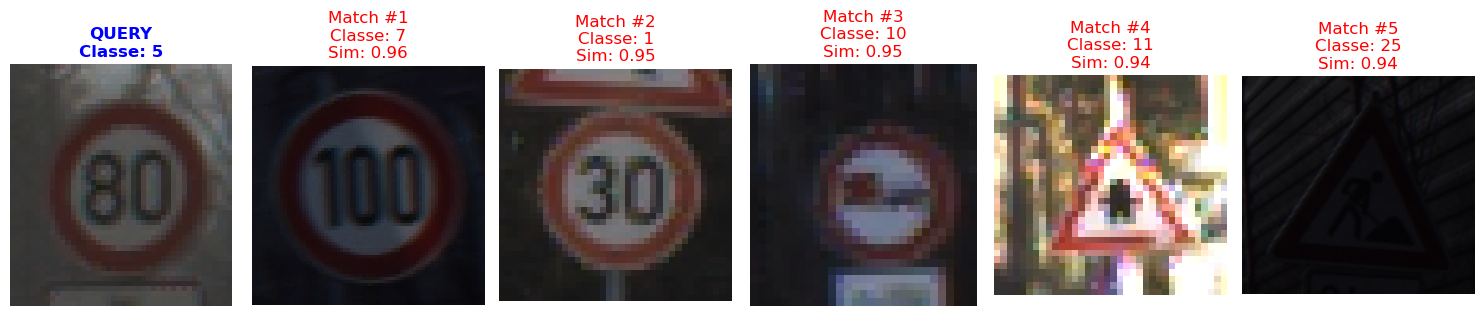

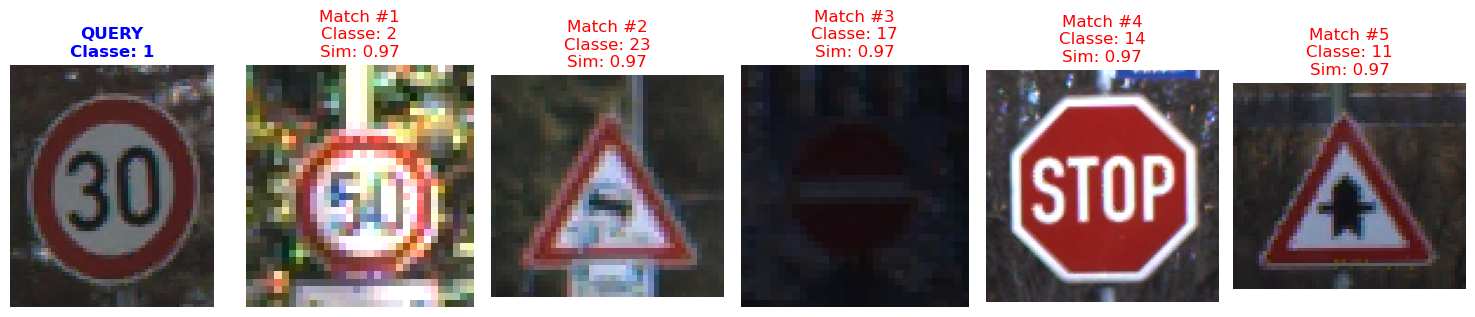

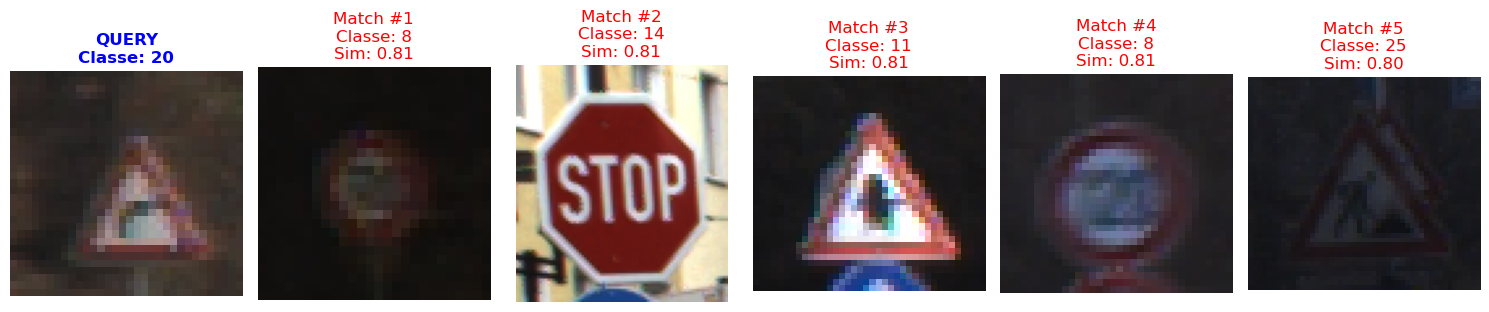

In [9]:
ds_vis_train = GTSRB(CFG["data_dir"], split="train", download=False)
ds_vis_test  = GTSRB(CFG["data_dir"], split="test",  download=False)

def visualize_retrieval(query_index, sim_matrix, k=5):
    query_img, query_label = ds_vis_test[query_index]
    topk_scores, topk_indices = torch.topk(sim_matrix[query_index], k)
    
    plt.figure(figsize=(15, 3))
    plt.subplot(1, k+1, 1)
    plt.imshow(query_img)
    plt.title(f"QUERY\nClasse: {query_label}", color="blue", fontweight="bold")
    plt.axis("off")
    
    for i in range(k):
        img, lbl = ds_vis_train[topk_indices[i].item()]
        plt.subplot(1, k+1, i+2)
        plt.imshow(img)
        color = "green" if lbl == query_label else "red"
        plt.title(f"Match #{i+1}\nClasse: {lbl}\nSim: {topk_scores[i]:.2f}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

for _ in range(3):
    visualize_retrieval(random.randint(0, len(ds_vis_test)-1), cos_matrix)

NMC nearest-mean-classifier

In [10]:
mean_features = torch.zeros(CFG["num_classes"], train_feats.shape[1])
for c in range(CFG["num_classes"]):
    mean_features[c] = train_feats[train_cls == c].mean(dim=0)

mean_features_norm = F.normalize(mean_features, p=2, dim=1)
distances          = torch.matmul(query_feats_norm, mean_features_norm.T)
nmc_preds          = distances.argmax(dim=1)

nmc_acc = (nmc_preds == test_cls).float().mean().item()
print(f"🎯 NMC Accuracy: {nmc_acc:.4f}")
print(classification_report(test_cls.numpy(), nmc_preds.numpy()))


🎯 NMC Accuracy: 0.3882
              precision    recall  f1-score   support

           0       0.06      0.35      0.10        60
           1       0.28      0.33      0.30       720
           2       0.31      0.21      0.25       750
           3       0.18      0.14      0.16       450
           4       0.33      0.29      0.31       660
           5       0.37      0.20      0.26       630
           6       0.53      0.86      0.65       150
           7       0.29      0.22      0.25       450
           8       0.18      0.24      0.20       450
           9       0.46      0.26      0.34       480
          10       0.53      0.60      0.56       660
          11       0.34      0.15      0.21       420
          12       0.89      0.91      0.90       690
          13       0.89      0.90      0.90       720
          14       0.96      0.70      0.81       270
          15       0.85      0.85      0.85       210
          16       0.38      0.79      0.52       150
    

pipeline con backbone avanzati (resnet 50)

In [11]:
def evaluate_map(sim_matrix, query_labels, gallery_labels):
    aps = []
    sim_np  = sim_matrix.numpy()
    q_np    = query_labels.numpy()
    g_np    = gallery_labels.numpy()
    for i in tqdm(range(len(q_np)), desc="Calcolo mAP"):
        y_true = (g_np == q_np[i]).astype(int)
        aps.append(average_precision_score(y_true, sim_np[i]))
    mAP = np.mean(aps)
    print(f"🎯 mAP: {mAP:.4f}")
    return mAP

def run_zero_shot_pipeline(model_name, device):
    print(f"\n{'='*60}\n🚀 {model_name.upper()}\n{'='*60}")
    
    m = get_model(model_name, weights="DEFAULT")
    m.fc = nn.Identity()
    m = m.to(device).eval()
    
    def extract(dl, desc):
        feats, labels = [], []
        with torch.no_grad():
            for imgs, lbls in tqdm(dl, desc=desc):
                imgs = TF.resize(imgs, [224, 224], antialias=True).to(device)
                feats.append(m(imgs).cpu())
                labels.append(lbls)
                torch.cuda.empty_cache()
        return torch.cat(feats), torch.cat(labels)
    
    gal_f, gal_l = extract(dl_train_real, "Gallery")
    qry_f, qry_l = extract(dl_test,       "Query")
    
    gal_fn = F.normalize(gal_f, p=2, dim=1)
    qry_fn = F.normalize(qry_f, p=2, dim=1)
    
    cos_mat = torch.matmul(qry_fn, gal_fn.T)
    map_score = evaluate_map(cos_mat, qry_l, gal_l)
    del cos_mat
    
    # NMC
    means = torch.zeros(CFG["num_classes"], gal_f.shape[1])
    for c in range(CFG["num_classes"]):
        means[c] = gal_f[gal_l == c].mean(dim=0)
    
    preds = torch.matmul(qry_fn, F.normalize(means, p=2, dim=1).T).argmax(dim=1)
    acc   = (preds == qry_l).float().mean().item()
    print(f"🎯 NMC Accuracy: {acc:.4f}")
    print(classification_report(qry_l.numpy(), preds.numpy(), zero_division=0))
    
    del m, gal_f, qry_f
    torch.cuda.empty_cache()
    return map_score, acc

# Lancia la pipeline — aggiungi altri backbone a piacere
for backbone_name in ["resnet50"]:
    run_zero_shot_pipeline(backbone_name, device)


🚀 RESNET50


Calcolo mAP: 100%|██████████| 12630/12630 [00:47<00:00, 265.24it/s]


🎯 mAP: 0.2195
🎯 NMC Accuracy: 0.4633
              precision    recall  f1-score   support

           0       0.01      0.05      0.01        60
           1       0.33      0.37      0.35       720
           2       0.41      0.17      0.25       750
           3       0.28      0.23      0.25       450
           4       0.47      0.35      0.40       660
           5       0.31      0.28      0.29       630
           6       0.68      0.98      0.80       150
           7       0.63      0.55      0.59       450
           8       0.19      0.22      0.21       450
           9       0.58      0.55      0.56       480
          10       0.51      0.51      0.51       660
          11       0.78      0.12      0.20       420
          12       1.00      0.92      0.96       690
          13       0.92      0.87      0.90       720
          14       0.88      0.77      0.82       270
          15       0.90      0.84      0.87       210
          16       0.47      0.77      0.58 